# CS909 Assignment 1
## Author: Jabir Hussain (2007942)

The goal of this assignment is to engineer a machine learning solution for an object recognition task. Each object is a 28x28 pixel image in the form of a flattened 784-dimensional vector, tagged with a label of +1 or -1.

The use of Generative AI for this assignment was primarily for grasping concepts: understanding cosine similarities specifically for image similarity, as well as looking at examples of where covariate shift has the most significant implications (and how we can overcome said cases using methods like KL-divergence).

In [37]:
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

# scikit learn imports
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    roc_auc_score, average_precision_score,
    f1_score, matthews_corrcoef,
    roc_curve, precision_recall_curve,
    auc,
    mean_squared_error
)


np.random.seed(2007942) # random seed with student id for reproducibility

### Question 1

**i. Dataset Overview**

Firstly, we want to identify how many examples of each class are in the training set and in the test set.

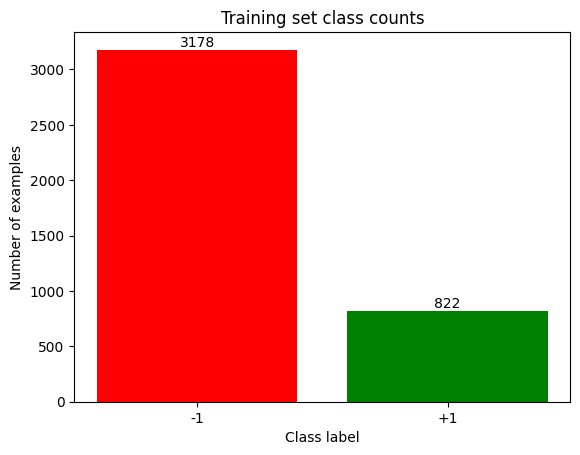

In [2]:
Xtrain = np.loadtxt("./Xtrain.csv")
Ytrain = np.loadtxt("./Ytrain.csv")
Xtest  = np.loadtxt("./Xtest.csv")

assert Xtrain.shape[0] == Ytrain.shape[0], "Number of training samples and labels must match."

classes, count = np.unique(Ytrain.astype(int), return_counts=True) # unique label values present in Ytrain (expected: -1 and +1)
train_count = pd.Series(count, index=classes).sort_index()         # create a pandas Series to display class counts in a readable format

fig, ax = plt.subplots()
ax.bar(train_count.index.astype(str), train_count.values, color=["red", "green"])
ax.set_title("Training set class counts")
ax.set_xlabel("Class label")
ax.set_ylabel("Number of examples")
ax.set_xticks([0, 1])
ax.set_xticklabels(["-1", "+1"])

for x, y in zip(train_count.index.astype(str), train_count.values):
    ax.text(x, y, str(int(y)), ha="center", va="bottom")

plt.show()

The dataset is significantly imbalanced: there are 3178 negative labels and 822 positive labels. Vanilla learner models will be biased towards negative values since they are in the majority, unless sufficient methods such as class weights or threshold tuning counteract it. In turn, model evaluation cannot rely on pure accuracy, as a model would score $79.5\%$ accuracy.

**ii. Visual Data Exploration**

We pick 10 objects at random to identify patterns and characteristics within the samples:

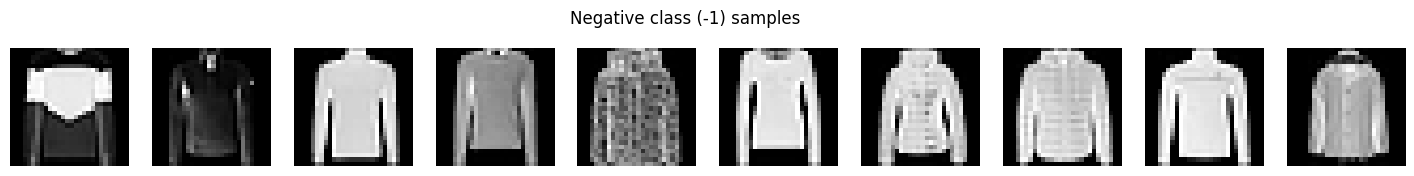

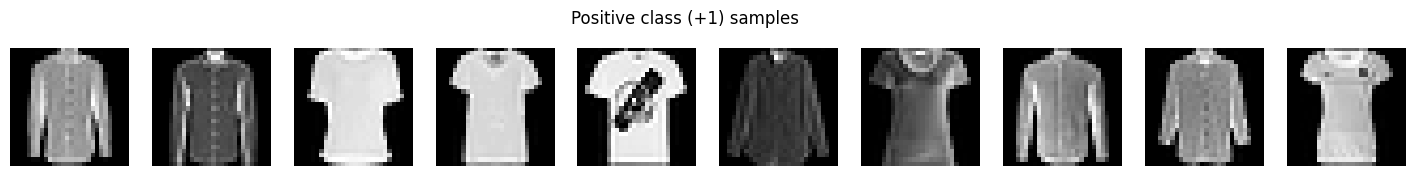

In [3]:
positive_index = np.where(Ytrain.astype(int) == 1)[0]
negative_index = np.where(Ytrain.astype(int) == -1)[0]

# sample 10 from each (without replacement)
pos_sample = np.random.choice(positive_index, size=10, replace=False)
neg_sample = np.random.choice(negative_index, size=10, replace=False)

fig, ax = plt.subplots(nrows=1, ncols=10, figsize=(18, 2))
for i, idx in enumerate(neg_sample):
    ax[i].matshow(Xtrain[idx].reshape(28, 28), cmap="gray")
    ax[i].axis("off")
plt.suptitle("Negative class (-1) samples")
plt.show()

fig, ax = plt.subplots(nrows=1, ncols=10, figsize=(18, 2))
for i, idx in enumerate(pos_sample):
    ax[i].matshow(Xtrain[idx].reshape(28, 28), cmap="gray")
    ax[i].axis("off")
plt.suptitle("Positive class (+1) samples")
plt.show()


The negative class consists of only long sleeve upper body clothing whereas the positive class is short sleeved upper body clothing or very specifically in some cases, long sleeved buttoned shirts. Both classes have different levels of brightness and textures, suggesting classification should be based on the geometry of the clothing item. The following images display 10 random objects from the test set.

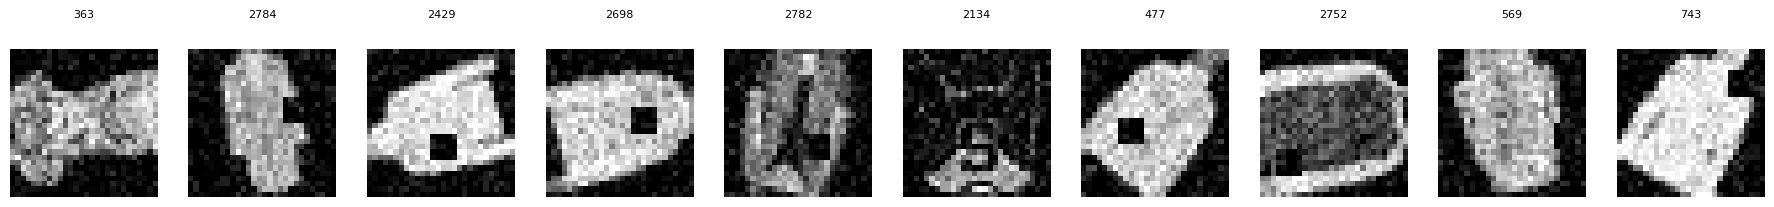

In [4]:
test_sample = np.random.choice(Xtest.shape[0], size=10, replace=False)

fig, axes = plt.subplots(nrows=1, ncols=10, figsize=(18, 2))

for i, idx in enumerate(test_sample):
    axes[i].matshow(Xtest[idx].reshape(28, 28), cmap="gray")
    axes[i].axis("off")
    axes[i].set_title(f"{idx}", fontsize=8)

plt.tight_layout()
plt.show()

The test set has several differences to the training set:
* Significant asymmetry: images are rotated, partially obstructed (by small black squares), and in some cases partially cropped. For models that rely on pixel position (such as kNN with Euclidean distance), there would be a degradation in performance.
* Lower resolution: images are grainier, so models that are overfit to clean training data would fail to classify noisy images. Models that rely on geometric distance would suffer from random pixel perturbations.

**iii. Choosing the Right Metric**:
There are a number of other metrics we can use to evaluate performance:
*   Accuracy: percentage of all correct classifications across classes (either positive or negative). It is defined by the equation $$\text{Accuracy} = \frac{\text{correct classifications}}{\text{total classifications}} = \frac{TP + TN}{TP + TN + FP + FN}$$ where $TP =$ true positive, $TN =$ true negative, $FP =$ false positive, $FN =$ false negative.
*   Balanced Accuracy: equal weight to both classes to mitigate score inflation on the majority class. It is given by the formula $$\frac{1}{2}\left(\frac{TP}{TP+FN} + \frac{TN}{TN+FP} \right)$$
*   F1 Score: harmonic mean of recall and precision for the positive class - $$\frac{2TP}{2TP + FN + FP}$$
*   Matthews Correlation Coefficient (MCC): the correlation between true and predicted labels, using all of the confusion matrix terms - $$\frac{TP\cdot TN - FP\cdot FN}{\sqrt{(TP + FP)(TP+FN)(TN+FP)(TN+FN)}}$$
*   Area Under the Receiver Operating Characteristic Curve (AUC-ROC): the probability a positive sample chosen at random receives a higher score than a negative random sample.
*   Area Under the Precision-Recall Curve (AUC-PR): average precision achieved per decision threshold sweep.

The single best metric for this dataset would be AUC-PR: it leverages the precision-recall trade-off, making it difficult for a model to exploit the majority class to reflect performance. The MCC would also offer a strong summary statistic as it does not reward majority prediction.

**iv: Benchmarking a Random Classifier**:

For a classifier that produces a random prediction score in the range $[-1, 1]$ for a given input example, the following metrics would be expected on both the testing and training sets. To evaluate how these metrics would perform, we define a series of helper functions:

In [5]:
ylabels = Ytrain.astype(int)
binary_labels = (ylabels == 1).astype(int) # convert to binary labels (1 for positive class, 0 for negative class)
pos_mean = binary_labels.mean() # positive prevalence in the training set

proxy_test_split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=2007942)
train_idx, holdout_idx = next(proxy_test_split.split(Xtrain, ylabels))

labels_train_signed = ylabels[train_idx]
labels_holdout_signed = ylabels[holdout_idx]
labels_train_binary = binary_labels[train_idx]
labels_holdout_binary = binary_labels[holdout_idx]

def generate_uniform_scores(n_samples):
    # i.i.d random prediction scores in [-1,1]
    return np.random.uniform(-1, 1, size=n_samples)

def evaluate_metrics(func, repeats=200):
    """
    Repeats a given metric function over random scores, returning the means and standard deviations
    for the test and holdout sets.
    """
    train_metrics, holdout_metrics = [], []
    for _ in range(repeats):
        all_scores = generate_uniform_scores(len(ylabels))
        train_metrics.append(func(all_scores, "train"))
        holdout_metrics.append(func(all_scores, "holdout"))

    return {
        "train_mean": np.mean(train_metrics),
        "train_std": np.std(train_metrics, ddof=1),
        "holdout_mean": np.mean(holdout_metrics),
        "holdout_std": np.std(holdout_metrics, ddof=1)
    }

For the AUC-ROC metric, the value should be approximately 0.5. The AUC-ROC is a probable measure that a random positive sample scores higher than a random negative sample. If samples are independent and identically distributed, both classes are equally likely to outrank each other. The experiment below explores this in code:

,train_mean,train_std,holdout_mean,holdout_std
AUC-ROC (random scores),0.49848,0.012359,0.502661,0.02795


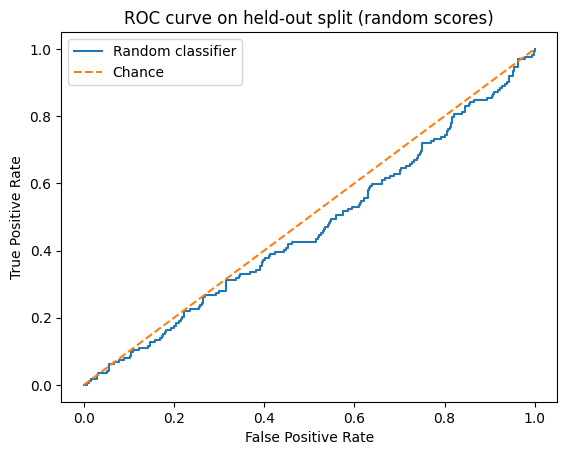

In [6]:
def compute_auc_roc(all_scores, split_name):
    if split_name == "train":
        return roc_auc_score(labels_train_binary, all_scores[train_idx])
    elif split_name == "holdout":
        return roc_auc_score(labels_holdout_binary, all_scores[holdout_idx])
    else:
        raise ValueError("split_name must be 'train' or 'holdout'")

aucroc_summary_stats = evaluate_metrics(compute_auc_roc)
display(pd.DataFrame([aucroc_summary_stats], index=["AUC-ROC (random scores)"]))

# ROC curve for a single run (holdout split)
one_run_scores = generate_uniform_scores(len(binary_labels))
fpr, tpr, _ = roc_curve(
    labels_holdout_binary, one_run_scores[holdout_idx]
)

plt.figure()
plt.plot(fpr, tpr, label="Random classifier")
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve on held-out split (random scores)")
plt.legend()
plt.show()


For the AUC-PR metric, we can expect the value to be close to the positive prevalence in the dataset, as defined in the variable `pos_mean`. Class imbalance affects the Precision-Recall performance; the expected precision for any recall level matches the base rate of positives for a given random ranker.

,train_mean,train_std,holdout_mean,holdout_std
AUC-PR (random scores),0.207731,0.007552,0.211952,0.0163


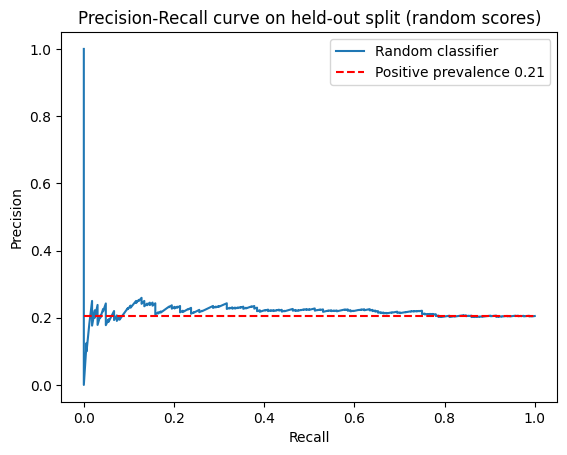

In [7]:
def auc_pr(score, split):
    if split == "train":
        return average_precision_score(labels_train_binary, score[train_idx])
    elif split == "holdout":
        return average_precision_score(labels_holdout_binary, score[holdout_idx])
    else:
        raise ValueError("split must be 'train' or 'holdout'")

aucpr_summary_stats = evaluate_metrics(auc_pr)
display(pd.DataFrame([aucpr_summary_stats], index=["AUC-PR (random scores)"]))

scores = generate_uniform_scores(len(binary_labels))
precision, recall, _ = precision_recall_curve(
    labels_holdout_binary, scores[holdout_idx]
)

plt.figure()
plt.plot(recall, precision, label="Random classifier")
plt.hlines(pos_mean, 0, 1, colors="red", linestyles="--", label=f"Positive prevalence {pos_mean:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve on held-out split (random scores)")
plt.legend()
plt.show()

For the F1 score, the value in this experiment is contingent on the decision thresholdd. Suppose we fix a threshold at 0, then we would have:

$$\text{threshold}=
    \begin{cases}
        1 & \text{if score} \ge 0\\
        -1 & \text{otherwise }
    \end{cases}
$$

As the scores are uniform on the interval $[-1, 1]$, we can expect the positives count to be roughly 50%. We can verify it through the following experiment:

In [8]:
threshold = 0.0

def preds_from_scores(scores, idx):
    return np.where(scores[idx] >= threshold, 1, -1)

def f1(scores, split):
    if split == "train":
        return f1_score(labels_train_signed, preds_from_scores(scores, train_idx), pos_label=1)
    elif split == "holdout":
        return f1_score(labels_holdout_signed, preds_from_scores(scores, holdout_idx), pos_label=1)
    else:
        raise ValueError("split must be 'train' or 'holdout'")

f1_summary_stats = evaluate_metrics(f1)
display(pd.DataFrame([f1_summary_stats], index=["F1 (random scores)"]))

,train_mean,train_std,holdout_mean,holdout_std
F1 (random scores),0.29232,0.009582,0.292259,0.020066


The Matthews Correlation Coefficient (MCC) is a metric we can use to measure correlation between the true and predicted labels; since the samples will be i.i.d., the MCC should be zero.

In [9]:
def mcc(scores, split):
    if split == "train":
        return matthews_corrcoef(labels_train_signed, preds_from_scores(scores, train_idx))
    elif split == "holdout":
        return matthews_corrcoef(labels_holdout_signed, preds_from_scores(scores, holdout_idx))
    else:
        raise ValueError("split must be 'train' or 'holdout'")

stats_mcc = evaluate_metrics(mcc)
display(pd.DataFrame([stats_mcc], index=["MCC (random scores)"]))


,train_mean,train_std,holdout_mean,holdout_std
MCC (random scores),0.000508,0.017094,-0.004612,0.034414


The mean squared error (MSE) between random samples and labels can be evaluated by the following:

$$\mathbb{E}[(y-s)^2] = \mathbb{E}[y^2] + \mathbb{E}[s^2] - 2\mathbb{E}[ys] = 1 + \frac{1}{3} - 0 = \frac{4}{3} \approx 1.33$$

,train_mean,train_std,holdout_mean,holdout_std
MSE (random scores),1.335761,0.019739,1.332525,0.038822


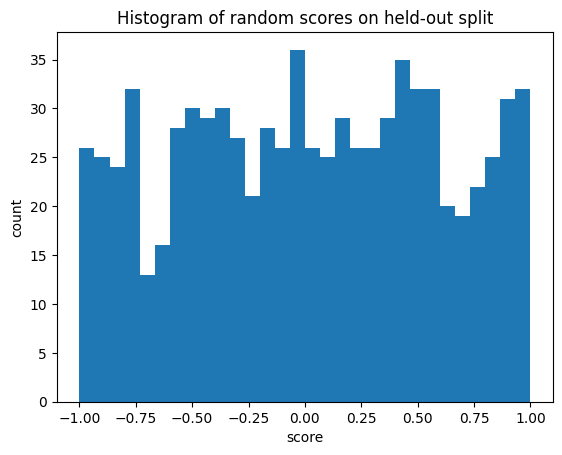

In [10]:
def mse(all_scores, split_name):
    if split_name == "train":
        return mean_squared_error(labels_train_signed, all_scores[train_idx])
    elif split_name == "holdout":
        return mean_squared_error(labels_holdout_signed, all_scores[holdout_idx])
    else:
        raise ValueError("split_name must be 'train' or 'holdout'")

stats_mse = evaluate_metrics(mse)
display(pd.DataFrame([stats_mse], index=["MSE (random scores)"]))


scores = generate_uniform_scores(len(ylabels))
plt.figure()
plt.hist(scores[holdout_idx], bins=30)
plt.xlabel("score")
plt.ylabel("count")
plt.title("Histogram of random scores on held-out split")
plt.show()

**v. Benchmarking a “Positive” Classifier**:

We now evaluate the metrics for a classifier that produces a positive label (+1) for any given input example. We will describe this classifier as a "Positive Classifier".

For the AUC-ROC metric, the classifier scores a constant score so there is no true ranking information, and positives and negatives appear the same in the scoring space. We would expect the AUC-ROC curve a diagonal line from (0,0) to (1,1), where the AUC-ROC is equal to 0.5 (equivalent to a random guess). There would be no standard deviation since this classifier would be deterministic.

,train_mean,train_std,holdout_mean,holdout_std
AUC-ROC (always +1),0.5,0.0,0.5,0.0


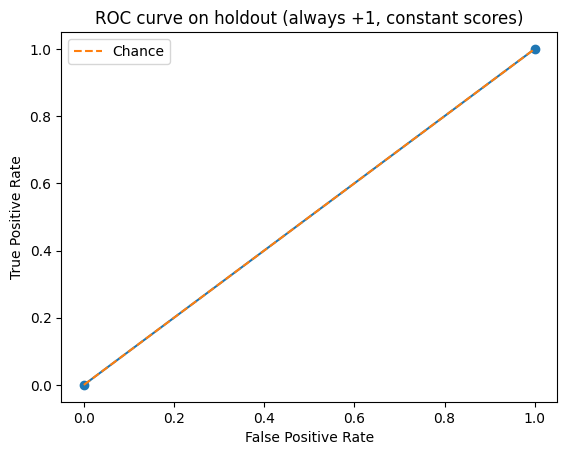

In [11]:
def generate_pos_predictions(n):
    return np.ones(n, dtype=int)

def constant_scores(n):
    return np.ones(n)

def roc_auc_pos(ytrue, yscore):
    try:
        return roc_auc_score(ytrue, yscore)
    except ValueError:
        return 0.5

def aucroc_positive_classifier(_, split):
    if split == "train":
        scores = constant_scores(len(train_idx))
        return roc_auc_pos(labels_train_binary, scores)
    elif split == "holdout":
        scores = constant_scores(len(holdout_idx))
        return roc_auc_pos(labels_holdout_binary, scores)
    else:
        raise ValueError("split must be 'train' or 'holdout'")

aucroc_stats = evaluate_metrics(aucroc_positive_classifier, repeats=50)  # repeats irrelevant; no randomness
display(pd.DataFrame([aucroc_stats], index=["AUC-ROC (always +1)"]))

# ROC curve on holdout: with constant scores, curve collapses to a point/degenerate line.
scores_holdout = constant_scores(len(holdout_idx))
fpr, tpr, _ = roc_curve(labels_holdout_binary, scores_holdout)

plt.figure()
plt.plot(fpr, tpr, marker="o")
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve on holdout (always +1, constant scores)")
plt.legend()
plt.show()


For the AUC-PR metric, the Positive Classifier reflects a constant score for each example. In turn, there's no ranking information. As the threshold varies, the classifier will predict all samples as positive or none whatsoever, yielding a precision equal to the positive prevalence. This provides a baseline, that any model with the AUC-PR close to this value has little to no meaningful class-separation ability.

,train_mean,train_std,holdout_mean,holdout_std
AUC-PR (always +1),0.205625,2.803737e-17,0.205,0.0


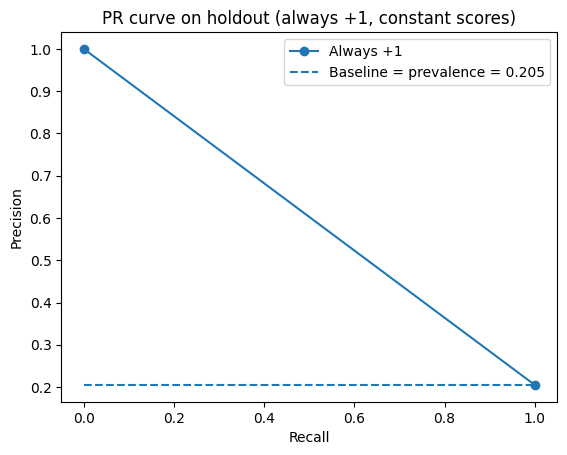

In [12]:
def auc_rc_pos(_, split):
    if split == "train":
        scores = constant_scores(len(train_idx))
        return average_precision_score(labels_train_binary, scores)
    elif split == "holdout":
        scores = constant_scores(len(holdout_idx))
        return average_precision_score(labels_holdout_binary, scores)
    else:
        raise ValueError("split must be 'train' or 'holdout'")

aucpr_stats = evaluate_metrics(auc_rc_pos, repeats=50)
display(pd.DataFrame([aucpr_stats], index=["AUC-PR (always +1)"]))

# PR curve on holdout (degenerate because scores are constant)
scores_holdout = constant_scores(len(holdout_idx))
precision, recall, _ = precision_recall_curve(labels_holdout_binary, scores_holdout)

plt.figure()
plt.plot(recall, precision, marker="o", label="Always +1")
plt.hlines(labels_holdout_binary.mean(), 0, 1, linestyles="--",
           label=f"Baseline = prevalence = {labels_holdout_binary.mean():.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR curve on holdout (always +1, constant scores)")
plt.legend()
plt.show()

With the Positive Classifier, we would expect the MCC to be close to 0: the MCC measures correlations between the predicted and true labels. For this specific classifier, there is no variation in prediction and in turn, little to no correlation.

In [13]:
def mcc_pos(_, split):
    if split == "train":
        preds = generate_pos_predictions(len(train_idx))
        return matthews_corrcoef(labels_train_signed, preds)
    elif split == "holdout":
        preds = generate_pos_predictions(len(holdout_idx))
        return matthews_corrcoef(labels_holdout_signed, preds)
    else:
        raise ValueError("split must be 'train' or 'holdout'")

mcc_stats = evaluate_metrics(mcc_pos)
display(pd.DataFrame([mcc_stats], index=["MCC (always +1)"]))


,train_mean,train_std,holdout_mean,holdout_std
MCC (always +1),0.0,0.0,0.0,0.0


For the MSE in this classification context, if $\hat{y}$ is always equal to $1$ then mistakes occur on negative examples, with probability $1 - \text{positive prevalence}$. Mathematically, this computes as $(-1 -1)^2 = 4 \implies 4(1 - 0.205) \approx 3.18$.

In [14]:
def mse_pos(_, split):
    if split == "train":
        preds = generate_pos_predictions(len(train_idx))
        return mean_squared_error(labels_train_signed, preds)
    elif split == "holdout":
        preds = generate_pos_predictions(len(holdout_idx))
        return mean_squared_error(labels_holdout_signed, preds)
    else:
        raise ValueError("split must be 'train' or 'holdout'")

mse_stats = evaluate_metrics(mse_pos)
display(pd.DataFrame([mse_stats], index=["MSE(y, yhat) (always +1)"]))

# Theoretical check: MSE = 4*(1 - prevalence)
print(f"Theoretical MSE(y,yhat) train   = {4*(1-labels_train_binary.mean()):.4f}")
print(f"Theoretical MSE(y,yhat) holdout = {4*(1-labels_holdout_binary.mean()):.4f}")


,train_mean,train_std,holdout_mean,holdout_std
"MSE(y, yhat) (always +1)",3.1775,8.904072e-16,3.18,0.0


Theoretical MSE(y,yhat) train   = 3.1775
Theoretical MSE(y,yhat) holdout = 3.1800


### Question 2

In this question, we look to perform a 5-fold stratified cross-validation over the training set using the k-nearest neighbour (kNN) algorithm.

**i. Can two images that look very similar to a human be far apart in Euclidean distance?**
This can be the case! Consider a change in brightness in an image, uniformally applied across all pixels. A human will still be able to identify that the image is the same, however Euclidean distance is dependent on pixel-based differences. For the images in the provided dataset, they have $d$ pixels where $d = 28 \times 28 = 784$. The Euclidean distance is evaluated via

$$ \mid \mid x - (x+c\mathbf{1}) \mid \mid_2 = \sqrt{\sum_{i=1}^d c^2} = \sqrt{dc^2} = \mid c \mid \sqrt{d})$$

Mathematically, this shows that for some change in brightness, the distance scales by 28, despite being identical images containing identical items from a human perspective. Translating this over to the kNN implementation this question looks to investigate, this could lead to misclassification.

Example index: 3745
Euclidean distance between original and brightness+25.0 version: 688.36


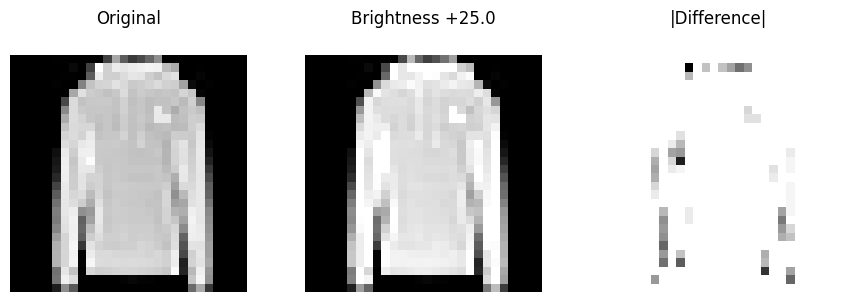

In [15]:
index = np.random.randint(0, Xtrain.shape[0])
img = Xtrain[index].reshape(28, 28)

c = 25.0
bright_vec = np.clip(img + c, 0, 255)

d = np.linalg.norm(img.ravel() - bright_vec.ravel())
print(f"Example index: {index}")
print(f"Euclidean distance between original and brightness+{c} version: {d:.2f}")

fig, ax = plt.subplots(1, 3, figsize=(9, 3))
ax[0].matshow(img, cmap="gray"); ax[0].set_title("Original"); ax[0].axis("off")
ax[1].matshow(bright_vec, cmap="gray"); ax[1].set_title(f"Brightness +{c}"); ax[1].axis("off")
ax[2].matshow(np.abs(img - bright_vec), cmap="gray"); ax[2].set_title("|Difference|"); ax[2].axis("off")
plt.tight_layout()
plt.show()

We now use a $k=5$ nearest neighbour classifier. For each fold, we will calculate the accuracy, baland accuracy, AUC-ROC, AUC-PR, F1 and MCC.

In [16]:
k = 5
strat_k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=2007942)

fold_metrics = []
outputs = {} # dict to store true y and predictions scores for plotting

for fold, (train, value) in enumerate(strat_k_fold.split(Xtrain, ylabels), start=1):
    Xtrain_fold, Xval_fold = Xtrain[train], Xtrain[value]
    ytrain_fold, yval_fold = ylabels[train], ylabels[value]
    yval_binary = binary_labels[value]

    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(Xtrain_fold, ytrain_fold)

    # prediction for threshold dependent metrics
    y_pred = knn.predict(Xval_fold)

    # P(class = 1) for AUC
    prob_a = knn.predict_proba(Xval_fold)
    pos_col = np.where(knn.classes_ == 1)[0][0]   # column corresponding to label +1
    pos_scores = prob_a[:, pos_col]

    fold_metrics.append({
        "fold": fold,
        "accuracy": accuracy_score(yval_fold, y_pred),
        "balanced_accuracy": balanced_accuracy_score(yval_fold, y_pred),
        "auc_roc": roc_auc_score(yval_binary, pos_scores),
        "auc_pr": average_precision_score(yval_binary, pos_scores),  # AP ≈ AUC-PR
        "f1": f1_score(yval_fold, y_pred, pos_label=1),
        "mcc": matthews_corrcoef(yval_fold, y_pred),
    })

    outputs[fold] = {
        "y_val_signed": yval_fold,
        "y_val_binary": yval_binary,
        "y_pred_signed": y_pred,
        "pos_scores": pos_scores
    }

fold_df = pd.DataFrame(fold_metrics).set_index("fold")
display(fold_df)

summary_df = pd.DataFrame({
    "mean": fold_df.mean(),
    "std": fold_df.std(ddof=1)
})
display(summary_df)


,accuracy,balanced_accuracy,auc_roc,auc_pr,f1,mcc
fold,,,,,,
1,0.94750,0.903628,0.947265,0.903532,0.866242,0.834948
2,0.93875,0.868711,0.920919,0.837281,0.833898,0.804484
3,0.94625,0.907367,0.945299,0.886490,0.865204,0.832186
4,0.93500,0.885039,0.944772,0.867617,0.835443,0.796257
5,0.92375,0.864495,0.924538,0.837539,0.805112,0.759620


,mean,std
accuracy,0.938250,0.009626
balanced_accuracy,0.885848,0.019554
auc_roc,0.936559,0.012724
auc_pr,0.866492,0.029431
f1,0.841180,0.025456
mcc,0.805499,0.030703


**iii: Plot the ROC and PR curves for one fold. What are your observations about the ROC and PR curves? What part of the ROC curve is more important for this problem and why?**

Now, we plot the ROC and PR curves for one fold; in this case, we will do fold 3.

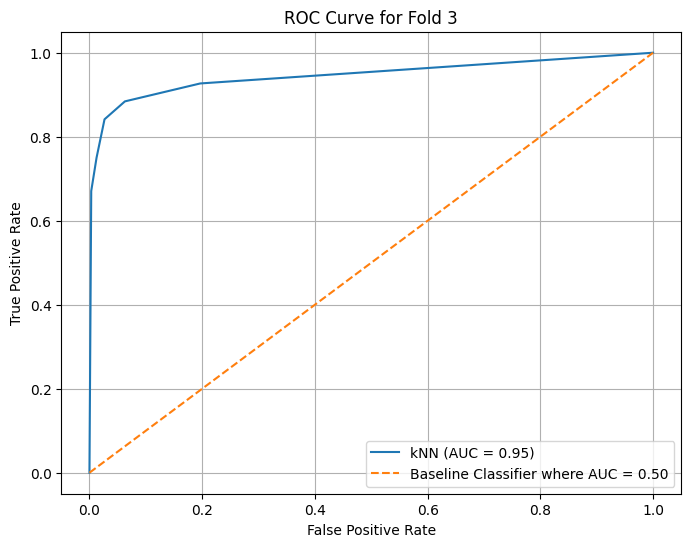

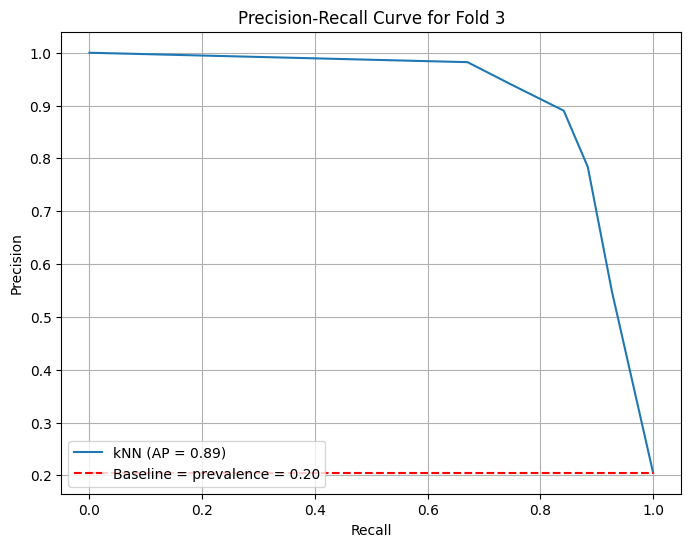

In [17]:
fold_to_plot = 3

# ROC Curve
y_val_binary_fold = outputs[fold_to_plot]["y_val_binary"]
pos_scores_fold = outputs[fold_to_plot]["pos_scores"]
fpr, tpr, _ = roc_curve(y_val_binary_fold, pos_scores_fold)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"kNN (AUC = {roc_auc_score(y_val_binary_fold, pos_scores_fold):.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Baseline Classifier where AUC = 0.50")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve for Fold {fold_to_plot}")
plt.legend()
plt.grid(True)
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_val_binary_fold, pos_scores_fold)
positive_prevalence_fold = y_val_binary_fold.mean()

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"kNN (AP = {average_precision_score(y_val_binary_fold, pos_scores_fold):.2f})")
plt.hlines(positive_prevalence_fold, 0, 1, colors="red", linestyles="--", label=f"Baseline = prevalence = {positive_prevalence_fold:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve for Fold {fold_to_plot}")
plt.legend()
plt.grid(True)
plt.show()

Given the imbalanced dataset, the most important segment of the ROC curve is the region with low false positive rate (the left-hand side). The ROC curve shows a steep rise near 0, demonstrating the classifiers high reall and low false positive rate. Mathematically, the TPR and FPR are given by

$$ TPR = \frac{TP}{N_+}, \quad FPR = \frac{FP}{N_-}$$ for $N_+$ is the positive count and $N_-$ is the negative count. For the imbalanced dataset, $N_- >> N_+$ so even small increases in FPR translates into a large number of false positives: $$FP = FPR\times N_-.$$

**iv: At what value of kkk would kNN become equivalent to a trivial classifier? Why?**

The classifier becomes trivial when $k=N$ where $N$ is the number of training samples for a given fold. When $k=N$, each training sample is considered a neighbour so the prediction only relies on the overall class proportions in the training set. Mathematically, we can write this as

$$\hat{y} = \arg\max \text{Pr}(y=c) \text{ for } c \in \{ -1, 1\}.$$

For this specific dataset, since the negative class comprises of 79.5% of the dataset, the kNN constantly predicts -1 for all of the inputs.

**v: Identify one training example that is consistently misclassified across folds. What does this tell you about the dataset rather than the model?**



In [18]:
from collections import Counter

misclassifications = Counter()

for train, value in strat_k_fold.split(Xtrain, ylabels):
  Xtrain_fold, Xval_fold = Xtrain[train], Xtrain[value]
  ytrain_fold, yval_fold = ylabels[train], ylabels[value]

  knn = KNeighborsClassifier(n_neighbors=5)
  knn.fit(Xtrain_fold, ytrain_fold)

  y_pred = knn.predict(Xval_fold)

  for index, pred, true in zip(value, y_pred, yval_fold):
    if pred != true:
      misclassifications[index] += 1

misclass = pd.DataFrame.from_dict(misclassifications, orient="index", columns=["misclassified"])
misclass = misclass.sort_values("misclassified", ascending=False)

display(misclass.head())

,misclassified
64,1
1813,1
1915,1
1939,1
2039,1


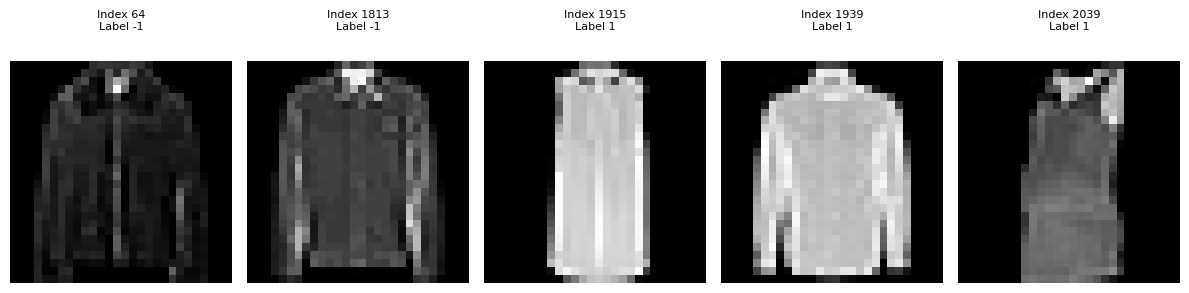

In [19]:
top5_indices = misclass.index[:5]

fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for ax, index in zip(axes, top5_indices):
    ax.matshow(Xtrain[index].reshape(28, 28), cmap="gray")
    ax.set_title(f"Index {index}\nLabel {ylabels[index]}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()


In these misclassified examples, there is significant image noise and unusual lighting. When using the kNN algorithm, the Euclidean distance is evaluated on raw pixels; given the nature of the images described before, the noise and lighting can significantly influence calculations. It is a limitation of feature representation rather than model classification.

### Question 3

In this question, we look to use 5-fold cross-validation over the training data to choose an optimal classifier between SVMs (linear, polynomial kernels and Radial Basis Function Kernels) and Random Forest (RF) classifiers.

In [33]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# crossval and scoring
strat_k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=2007942)
scoring = {
    "accuracy" : "accuracy",
    "balanced_accuracy" : "balanced_accuracy",
    "auc_roc": "roc_auc",
    "auc_pr" : "average_precision"
}

main_metric = "auc_pr" # due to imbalance

# we define a helper function for the grid search to return the results in a
# meaningful manner

def helper_gs(name, models, params):
  grid = GridSearchCV(
      estimator=models,
      param_grid=params,
      scoring=scoring,
      refit=main_metric,
      cv=strat_k_fold,
      verbose=1,
      n_jobs=-1,
      return_train_score=False
  )

  grid.fit(Xtrain, ylabels)
  best_index = grid.best_index_

  cvres = grid.cv_results_

  output = {
      "model": name,
      "best_params": grid.best_params_,
      "best_refit_metric": main_metric
  }

  for metric_name in scoring.keys():
    output[f"{metric_name}_mean"] = cvres[f"mean_test_{metric_name}"][best_index]
    output[f"{metric_name}_std"]  = cvres[f"std_test_{metric_name}"][best_index]

  return output, grid

Now we define the models specified in the question task using the scikit-learn's `Pipeline` class.

In [34]:
linear_svm = Pipeline([
    ("scalar", "passthrough"),
     ("clf", SVC(kernel="linear", probability=True, class_weight="balanced", random_state=2007942)),

])

linear_svm_params = {
    "scalar": ["passthrough", StandardScaler(), MinMaxScaler()],
    "clf__C": [0.1, 1, 10],
}

poly_svm = Pipeline([
    ("scalar", "passthrough"),
    ("clf", SVC(kernel="poly", probability=True, class_weight="balanced", random_state=2007942)),
])

poly_svm_params = {
    "scalar": [StandardScaler(), MinMaxScaler()],
    "clf__C": [0.1, 1, 10],
    "clf__degree": [2, 3, 4],
    "clf__gamma": ["scale", "auto"],
    "clf__coef0": [0.0, 1.0],
}

rbf_svm = Pipeline([
    ("scalar", "passthrough"),
    ("clf", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=2007942)),
])

rbf_svm_params = {
    "scalar": [StandardScaler(), MinMaxScaler()],
    "clf__C": [0.1, 1, 10],
    "clf__gamma": ["scale", "auto", 1e-3, 1e-2],
}

rf = RandomForestClassifier(random_state=2007942, class_weight="balanced", n_jobs=-1)
rf_params = {
    "n_estimators" : [50, 100, 200],
    "max_depth" : [None, 10, 20],
    "min_samples_split" : [2, 10],
    "min_samples_leaf": [1, 5],
    "max_features" : ["sqrt", "log2"]
}

We now run all the grid searches

In [35]:
from tqdm.auto import tqdm

search_results = []
grid_results = {}

model_specs = [
    ("Linear SVM", linear_svm, linear_svm_params),
    ("Poly SVM", poly_svm, poly_svm_params),
    ("RBF SVM", rbf_svm, rbf_svm_params),
    ("Random Forest", rf, rf_params),
]

for model_name, model_obj, param_grid in tqdm(model_specs, desc="Grid searches (model families)"):
    result, grid = helper_gs(model_name, model_obj, param_grid)
    search_results.append(result)
    grid_results[model_name] = grid

results_df = pd.DataFrame(search_results)

mean_std = lambda mean, std: [f"{m:.4f} \u00b1 {s:.4f}" for m, s in zip(mean, std)]

summary_stats = pd.DataFrame({
    "Model": results_df["model"],
    "Best parameters": results_df["best_params"].astype(str),
    "Accuracy": mean_std(results_df["accuracy_mean"], results_df["accuracy_std"]),
    "Balanced Acc": mean_std(results_df["balanced_accuracy_mean"], results_df["balanced_accuracy_std"]),
    "AUC-ROC": mean_std(results_df["auc_roc_mean"], results_df["auc_roc_std"]),
    "AUC-PR": mean_std(results_df["auc_pr_mean"], results_df["auc_pr_std"]),
})

sorted_results = results_df.sort_values("auc_pr_mean", ascending=False).reset_index(drop=True)
sorted_summary = summary_stats.iloc[sorted_results.index].reset_index(drop=True)

display(sorted_summary)

best_overall_name = sorted_results.loc[0, "model"]
best_overall_params = sorted_results.loc[0, "best_params"]
print("Best overall model (by mean AUC-PR):", best_overall_name)
print("Best overall hyperparameters:", best_overall_params)

Grid searches (model families):   0%|          | 0/4 [00:00<?, ?it/s]

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 72 candidates, totalling 360 fits


,Model,Best parameters,Accuracy,Balanced Acc,AUC-ROC,AUC-PR
0,Linear SVM,"{'clf__C': 0.1, 'scalar': MinMaxScaler()}",0.9143 ± 0.0168,0.9041 ± 0.0282,0.9537 ± 0.0200,0.9036 ± 0.0385
1,Poly SVM,"{'clf__C': 1, 'clf__coef0': 1.0, 'clf__degree'...",0.9422 ± 0.0136,0.9109 ± 0.0202,0.9615 ± 0.0189,0.9178 ± 0.0317
2,RBF SVM,"{'clf__C': 10, 'clf__gamma': 'scale', 'scalar'...",0.9385 ± 0.0145,0.9131 ± 0.0224,0.9623 ± 0.0168,0.9195 ± 0.0275
3,Random Forest,"{'max_depth': 20, 'max_features': 'sqrt', 'min...",0.9367 ± 0.0139,0.8948 ± 0.0234,0.9639 ± 0.0139,0.9214 ± 0.0233


Best overall model (by mean AUC-PR): Random Forest
Best overall hyperparameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 200}


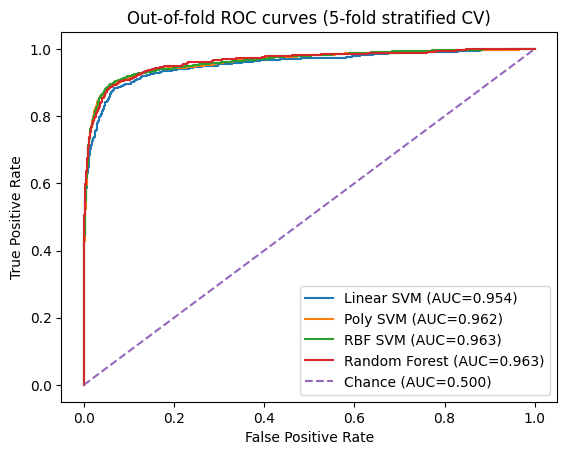

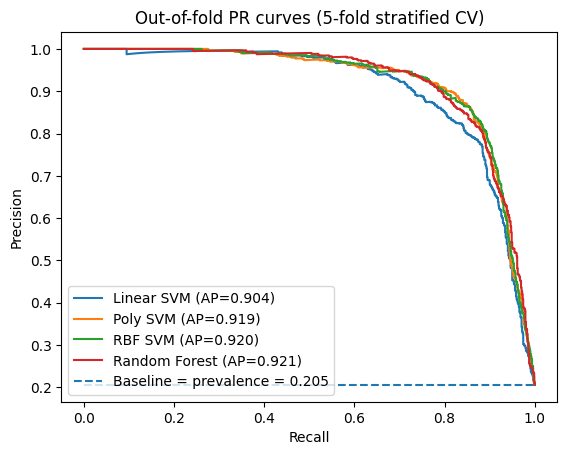

In [ ]:
from sklearn.base import clone

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2007942)

def out_of_fold(best_estimator, X, y_signed, y_binary, cv):
    oof_scores = np.zeros(len(y_signed), dtype=float)

    for train, val in cv.split(X, y_signed):
        X_tr, X_va = X[train], X[val]
        y_tr = y_signed[train]

        model = clone(best_estimator)
        model.fit(X_tr, y_tr)
        
        if hasattr(model, "decision_function"):
            scores = model.decision_function(X_va)
        else:
            proba = model.predict_proba(X_va)
            pos_col = np.where(model.classes_ == 1)[0][0]
            scores = proba[:, pos_col]

        oof_scores[val] = scores
    return oof_scores

best_models = {
    "Linear SVM": grid_results["Linear SVM"].best_estimator_,
    "Poly SVM": grid_results["Poly SVM"].best_estimator_,
    "RBF SVM": grid_results["RBF SVM"].best_estimator_,
    "Random Forest": grid_results["Random Forest"].best_estimator_,
}

scores_dict = {}
for name, est in best_models.items():
    scores_dict[name] = out_of_fold(est, Xtrain, ylabels, binary_labels, cv)

plt.figure()
for name, scores in scores_dict.items():
    fpr, tpr, _ = roc_curve(binary_labels, scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Chance (AUC=0.500)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Out-of-fold ROC curves (5-fold stratified CV)")
plt.legend()
plt.show()


plt.figure()
prevalence = binary_labels.mean()
for name, scores in scores_dict.items():
    precision, recall, _ = precision_recall_curve(binary_labels, scores)
    ap = average_precision_score(binary_labels, scores)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

plt.hlines(prevalence, 0, 1, linestyles="--", label=f"Baseline = prevalence = {prevalence:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Out-of-fold PR curves (5-fold stratified CV)")
plt.legend()
plt.show()

All of the classifiers show high AUC-ROC values, showing that all the different methods successfully identify the different classes. All of the curves has a sharp rise near the plots origin, signalling the high TPR at low FPR. This suggests a significant portion of the positives are detected before most negatives are misclassified. The curves are nearly identical for all the models apart from the Linear SVM.

For the PR curves, there is a more distinct difference in model performance. The average precision ranges from $\approx 0.9$ to $\approx 0.92$. The RF model and RBF SVM show a slightly better precision across the recall values, showing stronger model performance for an imbalanced dataset like this.

Multiple classifiers can have near identical ROC curves despite a difference in number of false positives. On the other hand, PR curves rely on precision, which can be affected by absolute false positives. Even a small number of increases can false positives can have adverse effects on precision, so the PR curve showcases performance better for imbalanced datasets. We can conclude that the PR curve is generally more reliable for deployment as it quantifies the precision-recall tradeoff, in turn quantifying the number of correct positive predictions. The final model of choice would be the Random Forest model.

### Question 4

**i. Plot the scree graph of PCA and find the number of dimensions that explain 95% variance in the training set. Then reduce the number of dimensions of the training data using PCA to 2 and plot a scatter plot of the training data showing examples of each class in a different color. What are your observations on the data based on the scree and scatter plots?**

Number of principal components to retain at least 95% variance: 99


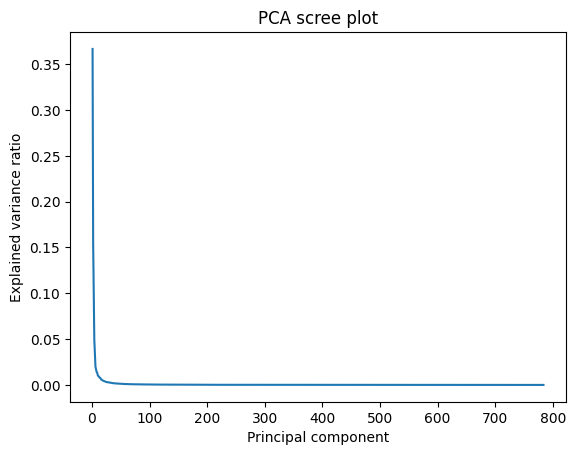

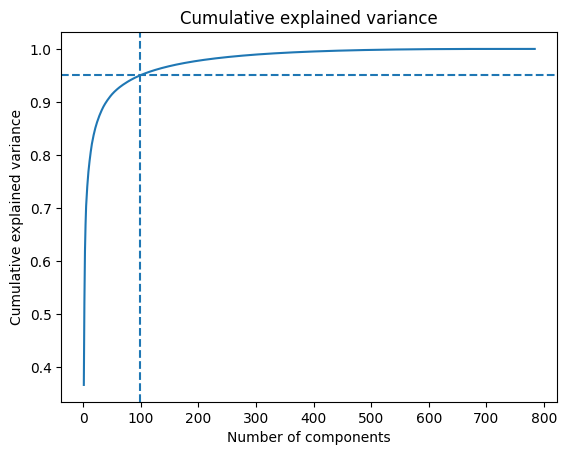

In [42]:
from sklearn.decomposition import PCA

pca = PCA(svd_solver="randomized", random_state=2007942)
pca.fit(Xtrain)

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)
n_components_95 = np.searchsorted(cumulative_explained_variance, 0.95) + 1
print(f"Number of principal components to retain at least 95% variance: {n_components_95}")

plt.figure()
plt.plot(np.arange(1, len(explained_variance_ratio) + 1), explained_variance_ratio)
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("PCA scree plot")
plt.show()

plt.figure()
plt.plot(np.arange(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance)
plt.axhline(0.95, linestyle="--")
plt.axvline(n_components_95, linestyle="--")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Cumulative explained variance")
plt.show()

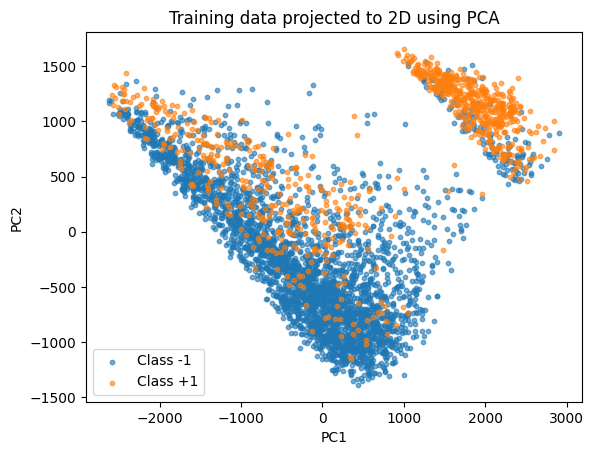

In [41]:
# now we reduce the dimensions to 2D and 
# plot a scatter plot of the training data showing examples of each class 
# in a different color
pca_2d = PCA(n_components=2, svd_solver="randomized", random_state=2007942)
Xtrain_2d = pca_2d.fit_transform(Xtrain)

plt.figure()
mask_neg = (ylabels == -1)
mask_pos = (ylabels == 1)

# Plot each class separately so matplotlib gives different default colors
plt.scatter(Xtrain_2d[mask_neg, 0], Xtrain_2d[mask_neg, 1], alpha=0.6, s=10, label="Class -1")
plt.scatter(Xtrain_2d[mask_pos, 0], Xtrain_2d[mask_pos, 1], alpha=0.6, s=10, label="Class +1")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Training data projected to 2D using PCA")
plt.legend()
plt.show()

From the scree plot, the first principal component represents a significant part of the variance. The 99 prinicipal components required to explain 95% of the variance shows large reduction in dimensionality as opposed to the original 784-dimensional pixel space, suggesting that the data can be represented in a lower-dimensional space. The curve is smooth suggesting variance is distributed across the multi-dimensional space rather than concentrated in particular components.

The 2D PCA projection shows partial class separation. There are distinct clusters for the different classes with visual overlap, primarily in the central space. These overlaps could be justified by a lack of linear separability with PC1 and PC2. The variance directions aren't fully representative of class boundaries since PCA maximises variance, hence why the RBF SVM and RF methods performed better than the linear model approach.

**ii: Reduce the number of dimensions of the training and test data together using PCA to 2 and plot a scatter plot of the training and test data showing examples of each set in a different color (or marker style). What are your observations about the data based on this plot? What would it imply if test points project outside the convex hull of training points in PCA space?**

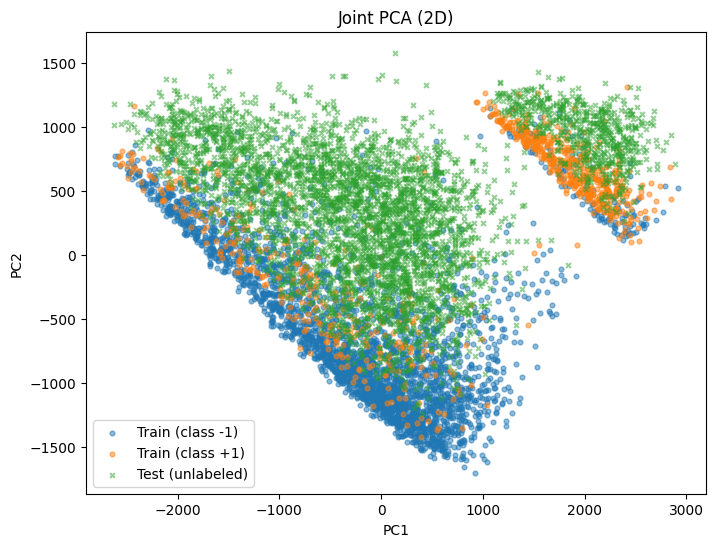

In [46]:
Xs = np.vstack([Xtrain, Xtest])
n_train = Xtrain.shape[0]

joint_2d_pca = PCA(n_components=2, svd_solver="randomized", random_state=2007942)
Xs_2d = joint_2d_pca.fit_transform(Xs)
Xtrain_2d = Xs_2d[:n_train]
Xtest_2d  = Xs_2d[n_train:]

plt.figure(figsize=(8, 6))

mask_neg = (ylabels == -1)
mask_pos = (ylabels == 1)
plt.scatter(Xtrain_2d[mask_neg, 0], Xtrain_2d[mask_neg, 1], s=12, alpha=0.5, marker="o", label="Train (class -1)")
plt.scatter(Xtrain_2d[mask_pos, 0], Xtrain_2d[mask_pos, 1], s=12, alpha=0.5, marker="o", label="Train (class +1)")
plt.scatter(Xtest_2d[:, 0], Xtest_2d[:, 1], s=12, alpha=0.5, marker="x", label="Test (unlabeled)")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Joint PCA (2D)")
plt.legend()
plt.show()

This joint PCA plot gives us key insights into the distributions of the train and test sets.
*   The test points have a clear overlap with the both classes, showing the feature distributions are the same. It also highlights that the test set data is similar to the training data, which is imperative for supervised learning
*   The overlapping regions provide further evidence for the point made in the previous text cell, that linear inseparability makes it difficult for linear models to correctly classify labels. This serves as further justification for using non-linear classification methods.

If the test points were to lie beyond the convex hull of training points, the model would have to extrapolate in the test cases. In turn, we could find distribution drift and model performance degradation.

**iii. Reduce the number of dimensions of the data using PCA and perform classification. You may want to select different principal components for the classification (not necessarily the first few). What is the (optimal) cross-validation performance of a Kernelized SVM classification with PCA? Remember to perform hyperparameter optimization!**

Firstly, we will perform dimensionality reduction via PCA. We want to avoid leaking information from validation folds in cross-validation; whilst a typical approach uses the first $k$ principal components with highest variance, this does not always correspond to strong class identification as PCA is an unsupervised method. The use of a supervised selection stage allows us to compute several principal components then use the ones with the best predictive performance using the ANOVA F-score statistic.

In [47]:
strat_k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=2007942)

scoring = {
    "accuracy" : "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "auc_roc": "roc_auc",
    "auc_pr": "average_precision"
}

main_metric = "auc_pr"

We will use PCA to reduce the 784-dimensional space into more stable orthogonal bases.

In [48]:
from sklearn.feature_selection import SelectKBest, f_classif
pca_selections = Pipeline([
    ("scalar", StandardScaler()),
    ("pca", PCA(svd_solver="randomized", random_state=2007942)),
    ("select", SelectKBest(score_func=f_classif)), 
    ("clf", SVC(class_weight="balanced", probability=True, random_state=2007942))
])

pca_selections_params = [
    {
        "pca__n_components": [100, 150, 200, 300],
        "select__k": [20, 50, 75, 100],
        "clf__kernel": ["rbf"],
        "clf__C": [0.1, 1, 10],
        "clf__gamma": ["scale", "auto", 1e-3, 1e-2],
    },
    {
        "pca__n_components": [100, 150, 200],
        "select__k": [20, 50, 75, 100],
        "clf__kernel": ["poly"],
        "clf__C": [0.1, 1, 10],
        "clf__degree": [2, 3],
        "clf__gamma": ["scale", "auto"],
        "clf__coef0": [0.0, 1.0],
    },
]

grid_search = GridSearchCV(
    estimator=pca_selections,
    param_grid=pca_selections_params,
    scoring=scoring,
    refit=main_metric,
    cv=strat_k_fold,
    verbose=1,
    n_jobs=-1,
    return_train_score=False
)

grid_search.fit(Xtrain, ylabels)
pca_best_index = grid_search.best_index_
pca_cvres = grid_search.cv_results_
print("Best parameters for PCA + feature selection + SVM:\n", grid_search.best_params_)

pca_summary_stats = []
for stat in ["accuracy", "balanced_accuracy", "auc_roc", "auc_pr"]:
    pca_summary_stats.append({
        "Metric": stat,
        "Mean ± Std": f"{pca_cvres[f'mean_test_{stat}'][pca_best_index]:.4f} ± {pca_cvres[f'std_test_{stat}'][pca_best_index]:.4f}"
    })

display(pd.DataFrame(pca_summary_stats))

Fitting 5 folds for each of 480 candidates, totalling 2400 fits
Best parameters for PCA + feature selection + SVM:
 {'clf__C': 10, 'clf__gamma': 0.001, 'clf__kernel': 'rbf', 'pca__n_components': 200, 'select__k': 100}


,Metric,Mean ± Std
0,accuracy,0.9345 ± 0.0147
1,balanced_accuracy,0.9178 ± 0.0224
2,auc_roc,0.9626 ± 0.0171
3,auc_pr,0.9188 ± 0.0268


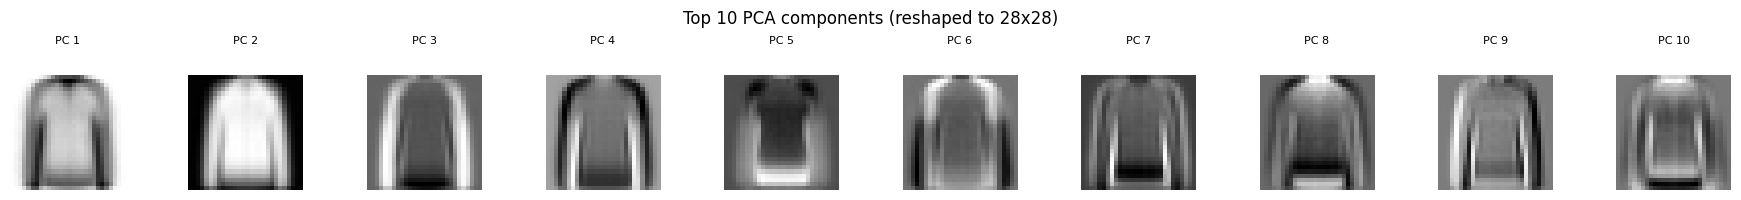

In [49]:
best_estimator = grid_search.best_estimator_
best_pca = best_estimator.named_steps["pca"]
n = 10
fig, axes = plt.subplots(1, n, figsize=(18, 2))
for i in range(n):
    ax = axes[i]
    ax.matshow(best_pca.components_[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"PC {i+1}", fontsize=8)
    ax.axis("off")

plt.suptitle("Top 10 PCA components (reshaped to 28x28)", fontsize=12)
plt.tight_layout()
plt.show()

PC1-PC4 are the most identifiable for a human. Despite the granularity of the images, the overall border, sleeve length and brightness contrast is easy to identify. For the latter PCs, the granularity and contrast becomes increasingly more difficult to identify which class each PC falls under. PCA orders components by explained variance in decreased order, hence why the PCs 1-4 are the best. As mentioned before, PCA doesn't maximise class identification, but total variance.

**v: By applying controlled transformations to the training data and refitting PCA, identify which principal component basis vectors are most affected by (i) uniform brightness increase, (ii) addition of random noise, (iii) randomisation of labels, (iv) horizontal
translation, and (v) rotation, and justify your conclusions using visual and quantitative evidence**

In [50]:
# helper fuctios for fitting pca, calculating cosine similarity
def fit_pca(X, n_components=50):
    pca = PCA(n_components=n_components, svd_solver="randomized", random_state=2007942)
    pca.fit(X)
    return pca

def cosine_similarity(original_pca, new_pca, k=10):
    original_components = original_pca.components_[:k]
    new_components = new_pca.components_[:k]
    similarities = np.abs(np.sum(original_components * new_components, axis=1))
    return similarities

def plot_first_n_pcs(pca, k=10, title_text=""):
    fig, axes = plt.subplots(1, k, figsize=(18, 2))
    for i in range(k):
        ax = axes[i]
        ax.matshow(pca.components_[i].reshape(28, 28), cmap="gray")
        ax.set_title(f"PC {i+1}", fontsize=8)
        ax.axis("off")
    plt.suptitle(title_text, fontsize=12)
    plt.tight_layout()
    plt.show()

def generate_report(name, transformed_X, original_pca, k=10):
    new_pca = fit_pca(transformed_X, n_components=k)
    similarities = cosine_similarity(original_pca, new_pca, k=k)
    print(f"Cosine similarities of top {k} PCs between original and {name}:")
    print(np.round(similarities, 3))
    most_affected = np.where(similarities < 0.5)[0]
    print("Most affected PCs (1-indexed):", (most_affected + 1).tolist())

    plt.figure(figsize=(8, 3))
    plt.bar(np.arange(1, k+1), similarities)
    plt.ylim(0, 1.05)
    plt.xlabel("PC index")
    plt.ylabel(r"$|\langle v_i, v'_i \rangle|$")
    plt.title(f"PC stability under transformation: {name}")
    plt.show()
    plot_first_n_pcs(original_pca, k=k, title_text=f"Top {k} PCs of original data")
    plot_first_n_pcs(new_pca, k=k, title_text=f"Top {k} PCs after {name}")

    return similarities, most_affected, new_pca

Cosine similarities of top 10 PCs between original and (i) Brightness +20.0:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Most affected PCs (1-indexed): []


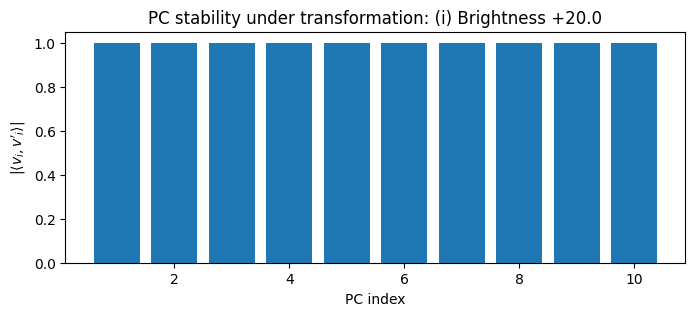

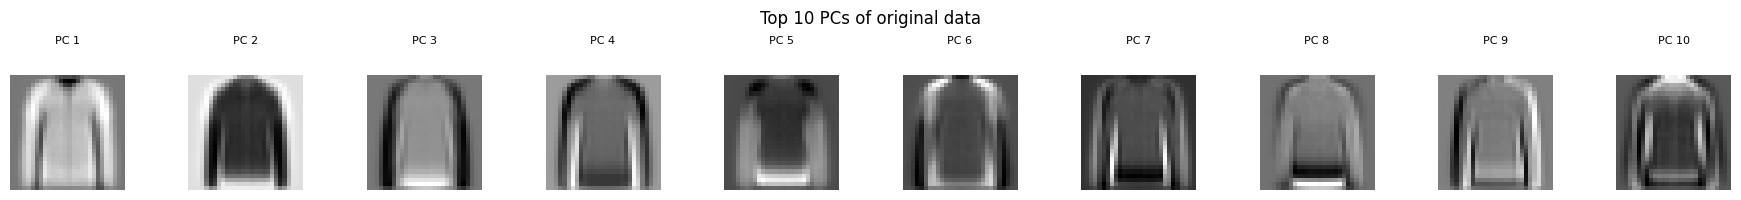

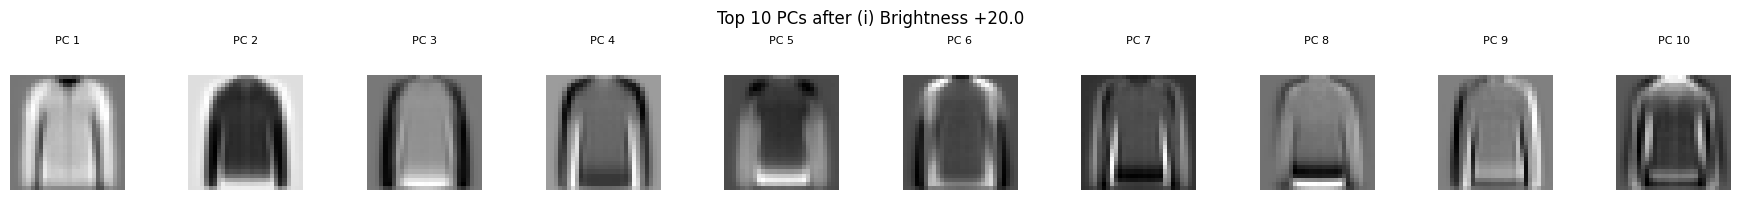

Cosine similarities of top 10 PCs between original and (ii) Gaussian noise sigma=10.0:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Most affected PCs (1-indexed): []


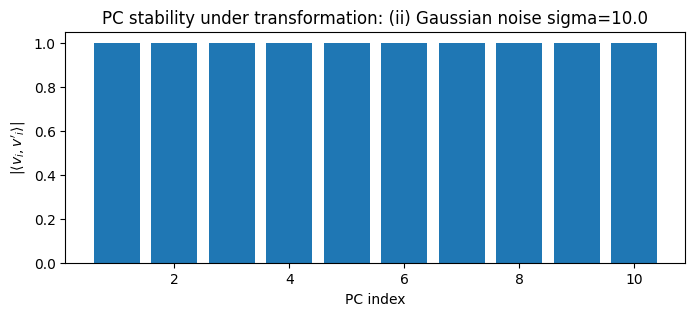

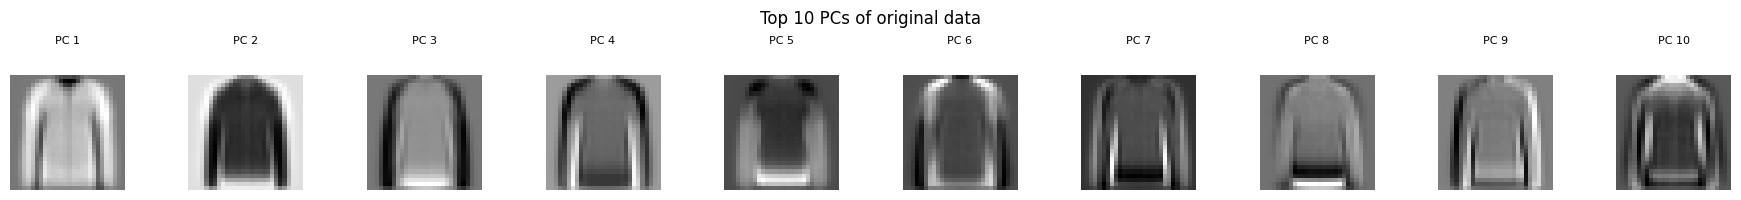

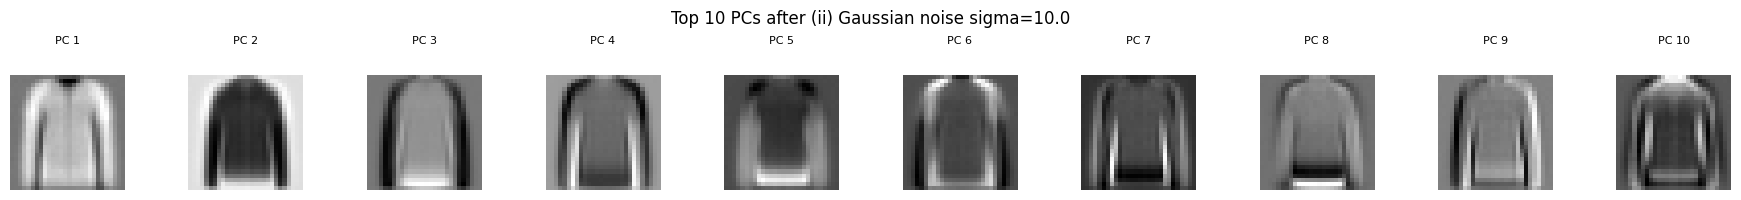

Cosine similarities of top 10 PCs between original and (iii) Randomised labels (X unchanged):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Most affected PCs (1-indexed): []


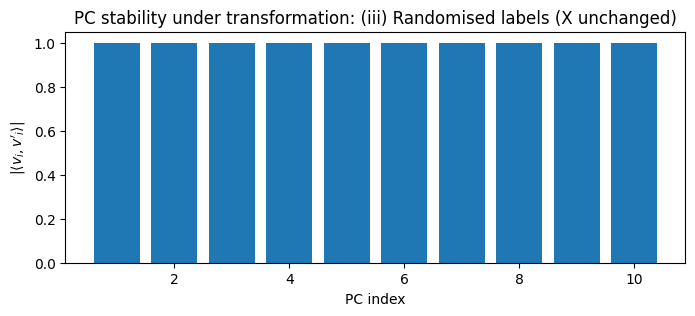

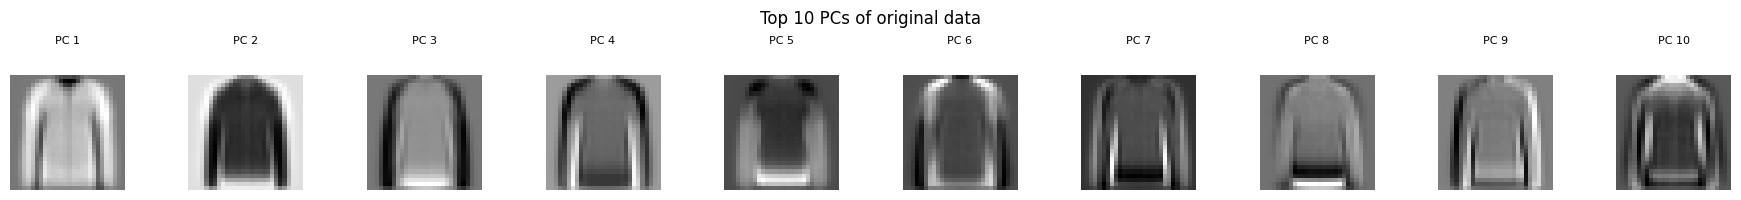

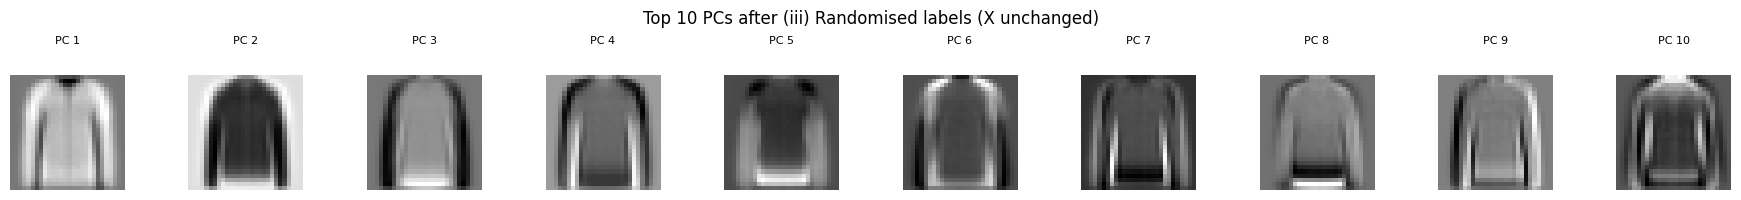

Cosine similarities of top 10 PCs between original and (iv) Horizontal shift 3px:
[0.981 0.511 0.184 0.176 0.679 0.021 0.02  0.503 0.095 0.287]
Most affected PCs (1-indexed): [3, 4, 6, 7, 9, 10]


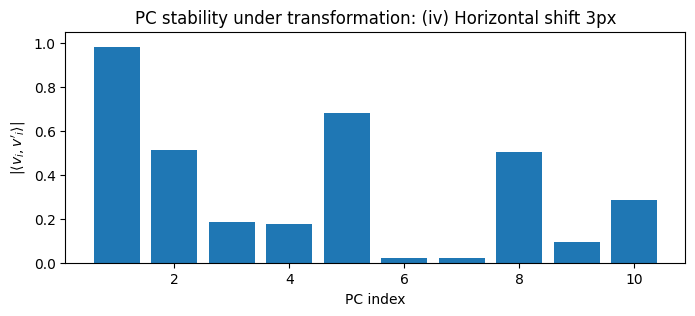

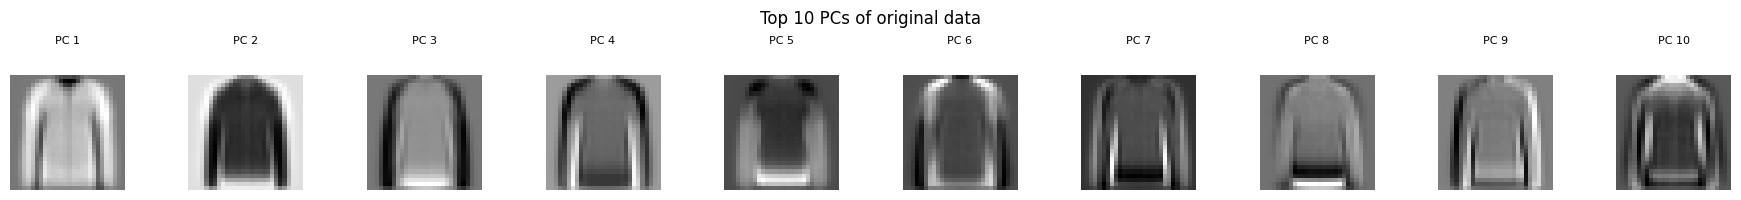

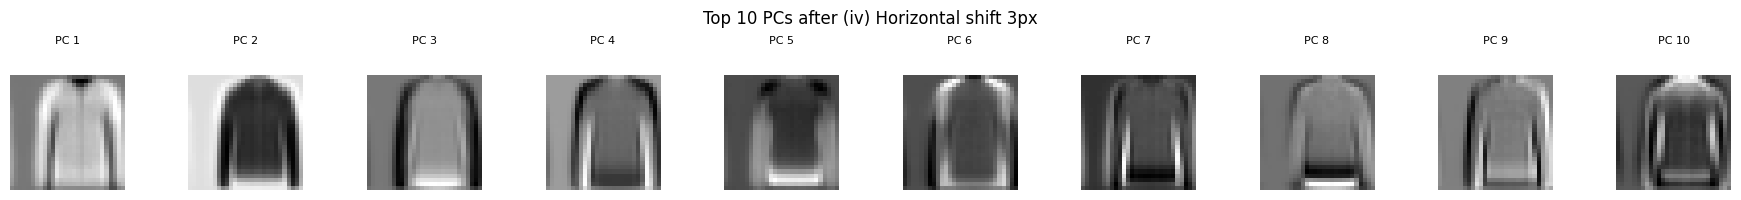

Cosine similarities of top 10 PCs between original and (v) Rotation 15°:
[0.99  0.78  0.591 0.315 0.839 0.317 0.121 0.525 0.228 0.444]
Most affected PCs (1-indexed): [4, 6, 7, 9, 10]


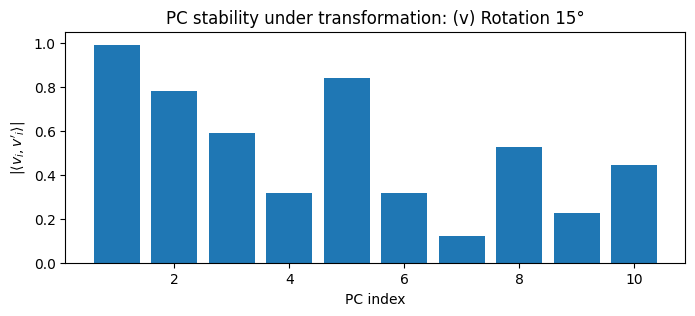

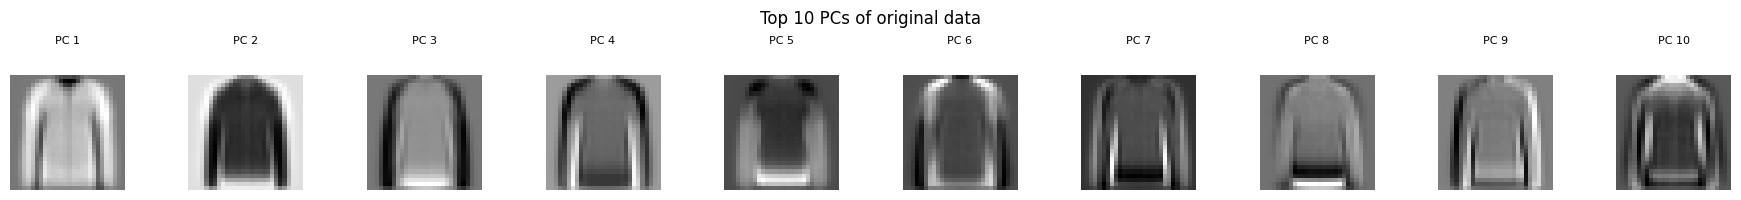

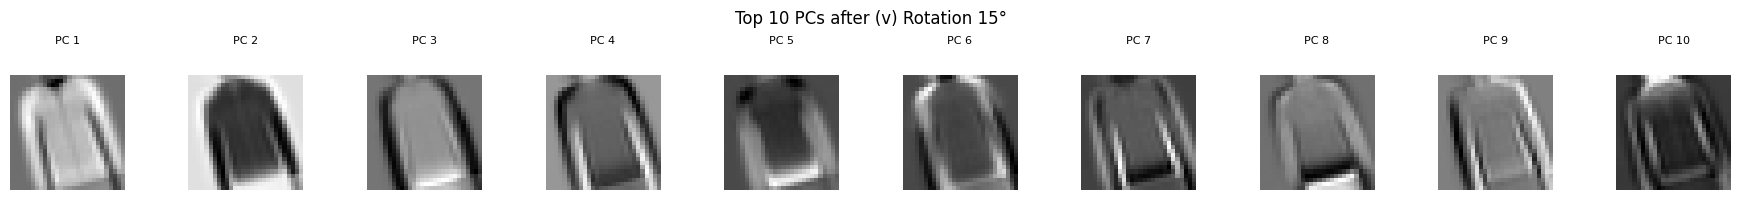

In [ ]:
from scipy.ndimage import rotate as nd_rotate

# Baseline PCA
pca_base = fit_pca(Xtrain, n_components=50)

# i. uniform brightness increase
delta = 20.0
X_bright = Xtrain + delta
generate_report(f"(i) Brightness +{delta}", X_bright, pca_base, k=10)

# ii. random noise
sigma = 10.0
X_noise = Xtrain + np.random.normal(0.0, sigma, size=Xtrain.shape)
generate_report(f"(ii) Gaussian noise sigma={sigma}", X_noise, pca_base, k=10)

# iii. label randomisation
generate_report("(iii) Randomised labels (X unchanged)", Xtrain, pca_base, k=10)

# (iv) Horizontal translation (roll)
shift_px = 3
X_shift = np.roll(Xtrain.reshape(-1, 28, 28), shift=shift_px, axis=2).reshape(-1, 784)
generate_report(f"(iv) Horizontal shift {shift_px}px", X_shift, pca_base, k=10)

# v. rotation
angle = 15
X_img = Xtrain.reshape(-1, 28, 28)
X_rot = np.stack([nd_rotate(im, angle=angle, reshape=False, mode="nearest") for im in X_img], axis=0).reshape(-1, 784)
generate_report(f"(v) Rotation {angle}°", X_rot, pca_base, k=10)

For the uniform brightness increase, the cosine similarities of the 10 principal components are all 1, showing no change in basis. Visually we can see this since the images before and after are extremely similar. Mathematically, the offset is represented by the equation $x' = x + \delta\mathbf{1}$, causing a mean shift with unchanged centred data. $$x' - \mu ' = (x+\delta\mathbf{1}) + (\,u + \delta\mathbf{1}) = x - \mu,$$ leaving the covariance and eigenvectors as invariant.

For the Gaussian noise, the 10 principal components remain relatively the same. The cosine similarities are roughly 1.0, and the transformed images look identical to the human eye. Noise doesn't have a significant change in the dominant directions of variance. Mathematically, i.i.d Gaussia noise adds $\sigma^2 I$ to the covariance matrix, bringing increasing the eigenvalues but not so much with the eigenvectors. In turn, the changes would primarily be in the higher index PCs.

Randomising the labels has no effect on covariance and in turn no change to the principal components.

We start seeing significant changes with the translation and rotational changes. In the translational case, cosine similarities have signficiant reductions. We can see a change in the images, and this is reflected through the PCA; shifting images changes the covariance matrices and in turn, rotates several principal modes of direction.

In the rotational case, cosine similarities also decrease. The images are clearly altered after the rotation, and this is reflected in the PCA. The rotation alters the covariance structure, affecting components sensitive to orientation.

### Question 5

**a. Define a binary classification task where each example is labelled by its origin: training set (−1) or test set (+1). Using 5-fold stratified cross-validation, train a classifier to solve this task and report the mean and standard deviation of the AUC-ROC.**


In [53]:
from sklearn.linear_model import LogisticRegression

train_set = Xtrain.shape[0]
test_set = Xtest.shape[0]
Xs = np.vstack([Xtrain, Xtest])
y_signed = np.concatenate([
    -np.ones(train_set, dtype=int),
    np.ones(test_set, dtype=int)
])

binary_labels = (y_signed == 1).astype(int)
strat_k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=2007942)

clf = Pipeline([
    ("scalar", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", random_state=2007942, max_iter=1000))
])

auc_scores = []
for fold, (train_i, val_i) in enumerate(strat_k_fold.split(Xs, y_signed), start=1):
    X_train, X_val = Xs[train_i], Xs[val_i]
    y_train, y_val = y_signed[train_i], y_signed[val_i]

    clf.fit(X_train, y_train)
    proba = clf.predict_proba(X_val)
    pos_cols = np.where(clf.named_steps["clf"].classes_ == 1)[0][0]
    pos_scores = proba[:, pos_cols]
    auc = roc_auc_score((y_val == 1).astype(int), pos_scores)
    auc_scores.append(auc)
    print(f"Fold {fold}: AUC-ROC = {auc:.4f}")

auc_mean = np.array(auc_scores).mean()
auc_stdev = np.array(auc_scores).std(ddof=1)
print(f"Mean AUC-ROC across folds: {auc_mean:.4f} ± {auc_stdev:.4f}")

display(
    pd.DataFrame({
        "Fold": np.arange(1, 6),
        "AUC-ROC": auc_scores
    }).set_index("Fold")
)

Fold 1: AUC-ROC = 0.9566
Fold 2: AUC-ROC = 0.9602
Fold 3: AUC-ROC = 0.9622
Fold 4: AUC-ROC = 0.9641
Fold 5: AUC-ROC = 0.9598
Mean AUC-ROC across folds: 0.9606 ± 0.0028


,AUC-ROC
Fold,
1,0.956627
2,0.960158
3,0.962248
4,0.964117
5,0.959772


We use a Logistic Regression classifier on the 784-dimensional pixel vectors.

The mean AUC-ROC is 0.9606 ± 0.0028, showing the classifier is very reliable with predicting whether an image comes from the test or training set. Earlier in the investigation, we clarified that specific attributes such as noise and rotation are part of the test set, detectable even with the class labels, and these results align with the earlier observations.

**b. Interpret the resulting AUC-ROC value as a measure of dataset shift. What does a value close to 0.5, moderately above 0.5, or close to 1.0 imply about the relationship between the training and test sets?**

A value close to 0.5 means the classifier cannot determine whether an image belongs to the training set or the test set. This would mean the feature distributions are similar with little to no covariate shift. For an AUC score of 0.5, cross-validation can reliably give insights to testing performance. 

A value moderately above 0.5 suggests slight covariate shift through artefacts such as brightness, noise, slight rotational/translation shift. Here, the classifier would exploit distributional biases rather than labelled information. In turn, model performance at test time could be worse, especially if the model is heavily biased for these shifts.

For an AUC-ROC close to 1.0, there is clear separation with the training and test sets. This shows significant covariate shift with a considerable number of artefacts between the two sets. The classifier recognises which dataset an image belongs too even without labels. We can interpret this as $p(X | train)$ and $p(X | test)$ having very different distributions in feature space.

For the classifier in 5a. with AUC-ROC 0.9606 ± 0.0028, the test set has significant difference to the training set that a simple classifier can detect.

**c. Identify which features or transformations of the data contribute most to separating training and test examples, and provide evidence to support your conclusion.**

Geometric shifts such as translation and rotation were exemplified through the results of Question 4, showing a noticeable reduction in cosine similarity of principal components. Models that rely on pixel values will interpret images differently under geometric shift, even if the differences are negligible to the human eye.

**d. Apply data augmentations (random noise and random rotations) to the training data and repeat the experiment. Analyse how and why the AUC-ROC changes, and what this reveals about the nature of the shift.**

In [59]:
def add_noise_and_rotate(X, noise=10.0, max_angle=45, clip=(0, 255)):
    X = np.asarray(X)

    if X.ndim == 1:
        X = X.reshape(-1, 784)

    if X.ndim != 2 or X.shape[1] != 784:
        raise ValueError(f"Expected X with shape (N, 784), got {X.shape}")

    images = X.reshape(-1, 28, 28)

    # Gaussian noise
    noisy_images = images + np.random.normal(0.0, noise, size=images.shape)

    # Per-image random rotation
    random_angles = np.random.uniform(-max_angle, max_angle, size=noisy_images.shape[0])
    rotated_images = np.stack([
        nd_rotate(im, angle=angle, reshape=False, mode="nearest")
        for im, angle in zip(noisy_images, random_angles)
    ], axis=0)

    if clip is not None:
        low, high = clip
        rotated_images = np.clip(rotated_images, low, high)

    return rotated_images.reshape(-1, 784)

aucs = np.array(auc_scores)
augmented_Xtrain = add_noise_and_rotate(
    Xtrain,
    noise=10.0,
    max_angle=45,
    clip=(0, 255)
)

# Build augmented origin dataset
X_aug = np.vstack([augmented_Xtrain, Xtest])
train_set = augmented_Xtrain.shape[0]
test_set = Xtest.shape[0]
y_signed_aug = np.concatenate([
    -np.ones(train_set, dtype=int),
     np.ones(test_set, dtype=int)
])
binary_labels_aug = (y_signed_aug == 1).astype(int)

# repeat origin AUC-ROC experiment (5-fold CV)
auc_scores_aug = []
strat_k_fold_aug = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=2007942
)

aug_clf = Pipeline([
    ("scalar", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",
        random_state=2007942,
        max_iter=5000,
        n_jobs=-1
    ))
])

for fold, (train_i, val_i) in enumerate(
    strat_k_fold_aug.split(X_aug, y_signed_aug),
    start=1
):
    X_train, X_val = X_aug[train_i], X_aug[val_i]
    y_train = y_signed_aug[train_i]
    y_val_bin = binary_labels_aug[val_i]

    aug_clf.fit(X_train, y_train)

    scores = aug_clf.decision_function(X_val)

    auc_scores_aug.append(
        roc_auc_score(y_val_bin, scores)
    )

aug_aucs = np.array(auc_scores_aug)
display(
    pd.DataFrame({
        "Fold": np.arange(1, 6),
        "AUC-ROC (original)": auc_scores,
        "AUC-ROC (augmented)": auc_scores_aug
    }).set_index("Fold")
)

print(f"Mean AUC-ROC (original): {aucs.mean():.4f} ± {aucs.std(ddof=1):.4f}")
print(f"Mean AUC-ROC (augmented): {aug_aucs.mean():.4f} ± {aug_aucs.std(ddof=1):.4f}")

/Users/jabir/msc_env/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/jabir/msc_env/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/jabir/msc_env/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/jabir/msc_env/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please

,AUC-ROC (original),AUC-ROC (augmented)
Fold,,
1,0.956627,0.823791
2,0.960158,0.815417
3,0.962248,0.827045
4,0.964117,0.824358
5,0.959772,0.828177


Mean AUC-ROC (original): 0.9606 ± 0.0028
Mean AUC-ROC (augmented): 0.8238 ± 0.0050


The AUC-ROC of the augmented dataset reduces slightly, dropping to around 0.8238. Even the rotations and Gaussian noise, the classifier can recognise which set the images belong to. From this, we can infer that test-train shift is not primarily governed through rotation and Gaussian noise, otherwise the AUC-ROC would be closer to 0.5. The shift does show that there is some component that is transformation-based.

**e. Explain how the presence of such a train–test distinction would affect your confidence in the evaluation of classifiers in earlier questions, and describe at least one principled strategy to reduce or eliminate this issue.**

These experiments have quantified that there is a difference between the training and testing sets. The majority of the assignment uses 5-fold stratified cross validation (CV) on the training set, where the underlying assumption is that $$p_{train}(X,Y) \approx p_{test}(X, Y).$$ If this was the case, a Logistic Regression classifier would not have such a high AUC-ROC score. From this, we gather that CV performance overestimates how well a classifier performs in test settings. The series of augmentations we've applied to the datasets affect the geometric representations of the data, which influence model performance directly. In turn, model peformance is partly subject to change with changes in the dataset rather than offering robust, generalised predictions. At the beginning of the assignment, I had decided AUC-PR was the optimal metric given the data imbalance, but all the threshold based metrics are contingent on the test and training sets having the same feature distribution. The distributional drift means the AUC-PR does not properly reflect performance.

A way we can mitigate this issue is the use of data augmentation. The original experiments showed high separability through the AUC-ROC score. The experiment in 5d. shows that this separability worsens when there's geometric transformations, suggesting that having these geometric transformations in the training data would emulate the test distribution. As a result, cross-validation is more robust and model perforance should improve.

### Question 6.

**a. Clearly describe the structure of your pipeline and justify each design choice in terms of the empirical findings from earlier questions, not generic best practices.**

*   Data Augmentation:
    * The original experiment yielded an AUC-ROC of 0.96, showing the covariate shift between the two sets. Since there was a reduction in AUC when noise and rotation was added, and the test set inspection in Question 1 showed these features too alongside others (i.e. random black squares, occluding the images), augmenting the training set with these variations should help the model generalise.
*   Standardisation:
    * Question 3 showed that model performance was subject to scaling before the SVM or not. SVM kernels rely on geometric representations, as does PCA variance, so scaling mitigates exploding variances dominating the feature representations.
*   Dimensionality Reduction:
    * The results of Question 4 shows that 95% of variance is represented in 99 components, reducing the dimensions from 784 significantly. The 2D PCA projection shows some linear separability, offering a stable representation of the data.
*   Classification Model implementation:
    * In Question 3, the Random Forest had the highest mean AUC-PR. The PCA results from Question 4 shows the non-linearity, which RF models capture effectively. Through balancing in the RF, the model can mitigate minority-class errors.
*   Quantifying Results:
    * Since there is a large imbalance in the dataset, the AUC-PR metric will be used as the primary metric, however AUC-ROC curves will also be plotted to show class separability. MCC will also be used to check the model isn't exploiting the class imbalance.

**b. Identify at least one plausible alternative pipeline that a competent practitioner might choose, explain why it is reasonable, and justify why you did not select it.**

An alternative pipeline is the use of a Convolutional Neural Network (CNN). A CNN offers a robust solution to geometric translations, championed as the primary computer vision method for modern machine learning. However, a CNN requires a significantly larger dataset, more compute for training and hyperparameter tuning that my personal computer does not have. Nevertheless, classical machine learning model offers deterministic cross-validation within a reasonable compute time.

**c. Pipeline + chosen stress test.**

In [71]:
ylabels = Ytrain.astype(int)
binary_labels = (ylabels == 1).astype(int)

### Data Augmentation
# Occlusion function
def occlude_image(images, size=6, fill=0.0, holes=1):
    size = int(size)
    holes = int(holes)
    images = np.asarray(images)
    N, H, W = images.shape
    occlude_images = images.copy()

    for i in range(N):
        for _ in range(holes):
            y = np.random.randint(0, H)
            x = np.random.randint(0, W)

            y_1 = max(0, y - size // 2)
            y_2 = min(H, y_1 + size)
            x_1 = max(0, x - size // 2)
            x_2 = min(W, x_1 + size)

            occlude_images[i, y_1:y_2, x_1:x_2] = fill

    return occlude_images

def augment_train_set(X, noise=10.0, max_angle=45, rotation=0.5, occlusion=True,
                      holes=1, hole_size=5, clip=(0, 255)):
    X = np.asarray(X)
    if X.ndim == 1:
        X = X.reshape(-1, 784)
    if X.ndim != 2 or X.shape[1] != 784:
        raise ValueError(f"Expected X with shape (N, 784), got {X.shape}")
    
    images = X.reshape(-1, 28, 28).astype(float)

    # add noise
    if noise > 0:
        images = images + np.random.normal(0.0, noise, size=images.shape)
    # occlusion
    if occlusion:
        images = occlude_image(images, size=hole_size, fill=0)
    # rotation
    if max_angle > 0 and rotation > 0:
        n = images.shape[0]
        masks = np.random.rand(n) < rotation
        random_angles = np.random.uniform(-max_angle, max_angle, size=n)

        for i in np.where(masks)[0]:
            images[i] = nd_rotate(images[i], angle=random_angles[i], reshape=False, mode="nearest")

    if clip is not None:
        low, high = clip
        images = np.clip(images, low, high)
    return images.reshape(-1, 784)

In [72]:
pca_comp_count = 99

# params from highest mean AUC-PR in prior grid search
rf_params = dict(
    n_estimators=200,
    max_depth=20,
    max_features="sqrt",
    min_samples_split=2,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=2007942,
    n_jobs=-1,
)

rf_pipeline = Pipeline([
    ("scalar", StandardScaler()),
    ("pca", PCA(n_components=pca_comp_count, svd_solver="randomized", random_state=2007942)),
    ("clf", RandomForestClassifier(**rf_params))
])

In [73]:
def evaluate_pipeline(X, y_signed, y_binary, pipeline, cv, augment=None):
    folds = []

    for fold, (train_i, val_i) in enumerate(cv.split(X, y_signed), start=1):
        X_train, X_val = X[train_i], X[val_i]
        y_train, y_val_signed = y_signed[train_i], y_signed[val_i]
        y_val_binary = y_binary[val_i]

        # augment training split only
        if augment is not None:
            X_trained = augment_train_set(X_train, **augment)
        else:
            X_trained = X_train

        pipeline.fit(X_trained, y_train)

        # evaluate on validation split
        proba = pipeline.predict_proba(X_val)
        pos_cols = np.where(pipeline.named_steps["clf"].classes_ == 1)[0][0]
        pos_scores = proba[:, pos_cols]

        y_pred = pipeline.predict(X_val)

        folds.append({
            "fold": fold,
            "auc_pr": average_precision_score(y_val_binary, pos_scores),
            "auc_roc": roc_auc_score(y_val_binary, pos_scores),
            "mcc": matthews_corrcoef(y_val_signed, y_pred),
        })

    fold_df = pd.DataFrame(folds).set_index("fold")
    summary_df = pd.DataFrame({
        "mean": fold_df.mean(),
        "std": fold_df.std(ddof=1)
    })
    return fold_df, summary_df

In [74]:
# baseline
strat_k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=2007942)

augment = dict(
    noise=10.0,
    max_angle=25.0,
    rotation=0.5,
    occlusion=True,
    holes=1,
    hole_size=6,
    clip=(0, 255),
)

fold_df_base, summary_base = evaluate_pipeline(
    Xtrain, ylabels, binary_labels, rf_pipeline, strat_k_fold, augment=augment
)

display(fold_df_base)
display(summary_base)

print("AUC-PR mean ± std:", f"{summary_base.loc['auc_pr', 'mean']:.4f} ± {summary_base.loc['auc_pr', 'std']:.4f}")
print("AUC-ROC mean ± std:", f"{summary_base.loc['auc_roc', 'mean']:.4f} ± {summary_base.loc['auc_roc', 'std']:.4f}")
print("MCC mean ± std:", f"{summary_base.loc['mcc', 'mean']:.4f} ± {summary_base.loc['mcc', 'std']:.4f}")

,auc_pr,auc_roc,mcc
fold,,,
1,0.896990,0.954863,0.788726
2,0.866075,0.934509,0.779565
3,0.892786,0.959359,0.766945
4,0.868563,0.949425,0.753246
5,0.823239,0.920181,0.674496


,mean,std
auc_pr,0.869530,0.029371
auc_roc,0.943667,0.016126
mcc,0.752596,0.045658


AUC-PR mean ± std: 0.8695 ± 0.0294
AUC-ROC mean ± std: 0.9437 ± 0.0161
MCC mean ± std: 0.7526 ± 0.0457


In [76]:
augment_stress = dict(
    noise=20.0,
    max_angle=45.0,
    rotation=0.75,
    occlusion=True,
    holes=2,
    hole_size=8,
    clip=(0, 255),
)

fold_df_stress, summary_stress = evaluate_pipeline(
    Xtrain, ylabels, binary_labels, rf_pipeline, strat_k_fold, augment=augment_stress
)
print("\nUnder stress conditions:")
display(fold_df_stress)
print("\nSummary under stress conditions:")
display(summary_stress)

# compare baseline vs stress
comparison = pd.DataFrame({
    "baseline_mean": summary_base["mean"],
    "baseline_std": summary_base["std"],
    "stress_mean": summary_stress["mean"],
    "stress_std": summary_stress["std"],
})
print("\nComparison of baseline vs stress:")
display(comparison)

print("Change under stress (stress_mean - baseline_mean):")
print((comparison["stress_mean"] - comparison["baseline_mean"]).to_string())

print("\nPrimary metric under baseline vs stress:")
print(f"AUC-PR baseline: {summary_base.loc['auc_pr','mean']:.4f} ± {summary_base.loc['auc_pr','std']:.4f}")
print(f"AUC-PR stress:   {summary_stress.loc['auc_pr','mean']:.4f} ± {summary_stress.loc['auc_pr','std']:.4f}")



Under stress conditions:


,auc_pr,auc_roc,mcc
fold,,,
1,0.855887,0.939101,0.737280
2,0.851241,0.916580,0.742367
3,0.872917,0.942600,0.742482
4,0.845041,0.943345,0.726174
5,0.811525,0.909415,0.672468



Summary under stress conditions:


,mean,std
auc_pr,0.847322,0.022530
auc_roc,0.930209,0.015994
mcc,0.724154,0.029645



Comparison of baseline vs stress:


,baseline_mean,baseline_std,stress_mean,stress_std
auc_pr,0.869530,0.029371,0.847322,0.022530
auc_roc,0.943667,0.016126,0.930209,0.015994
mcc,0.752596,0.045658,0.724154,0.029645


Change under stress (stress_mean - baseline_mean):
auc_pr    -0.022208
auc_roc   -0.013459
mcc       -0.028442

Primary metric under baseline vs stress:
AUC-PR baseline: 0.8695 ± 0.0294
AUC-PR stress:   0.8473 ± 0.0225


Under the stress test which uses maximal data augmentation, the performance reduces slightly. This pipeline shows it is somewhat robust to dataset corruption.

In [77]:
Xtrain_final = augment_train_set(Xtrain, **augment)

rf_pipeline.fit(Xtrain_final, ylabels)
test_proba = rf_pipeline.predict_proba(Xtest)
pos_col = np.where(rf_pipeline.named_steps["clf"].classes_ == 1)[0][0]
test_scores = test_proba[:, pos_col]
submission_df = pd.DataFrame(test_scores)
submission_df.to_csv("u2007942.csv", index=False, header=False)

print("Saved submission file: u2007942.csv")
print("Rows:", submission_df.shape[0], "| Cols:", submission_df.shape[1])

Saved submission file: u2007942.csv
Rows: 4000 | Cols: 1


**e. Explicitly state the main assumption your pipeline relies on, and discuss how violating this assumption would affect your conclusions.**

The pipeline assumes covariate shift, hence the use of data augmentation. If the conditional relationship between the test and training sets changed, then the geometric translations introduced wouldn't always yield generalisation.